<h1>Decision Trees for Classification and Regression</h1>

Decision trees are a common machine learning model used for binary classifcation as well as regression. Some examples include prediciting whether a student passes a test, whether an email is spam, if a transaction is legitimate. 

A decision tree is traversed sequentially until the final outcome is reached. At each leaf in the tree, a logical statement is evaluated which determines the path the tree is traversed. 

In this notebook, both binary classifcation and regression will be explored using decision trees. The data used is from kaggle and represents graduate admission from India: https://www.kaggle.com/datasets/mohansacharya/graduate-admissions

<h2>Dataset</h2>
The data consists of features used to determine an admission into a masters degree.

 - GRE Scores ( out of 340 )
 - TOEFL Scores ( out of 120 )
 - University Rating ( out of 5 )
 - Statement of Purpose and Letter of Recommendation Strength ( out of 5 )
 - Undergraduate GPA ( out of 10 )
 - Research Experience ( either 0 or 1 )
 - Chance of Admit ( ranging from 0 to 1 )


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("/Users/jai/Documents/GitHub/MachineLearningPortfolio/DecisionTrees/AdmissionsPredict/Admission_Predict_Ver1.1.csv")
df.columns = df.columns.str.strip().str.replace(' ','_').str.lower()
df.columns

Index(['serial_no.', 'gre_score', 'toefl_score', 'university_rating', 'sop',
       'lor', 'cgpa', 'research', 'chance_of_admit'],
      dtype='object')

<h1>Step 1</h1> 

Create a binary classifccation. 1 = admission likely, 0 = adminsstion unlikely.

Chance of admission <code>chance_of_admit</code> greater than 0.8 constitutes to a 1, 0 otherwise.

In [4]:
# X is the predictor variables
X = df.loc[:,'gre_score':'research']
# y is the outcome
y = df["chance_of_admit"]>=0.8

<h1>Step 2</h2>
Fitting and Predicting using scikit-learn built in tree modules. 

The steps are the same for other modules. <code>DecisionTreeClassifier()</code> is used to instantiate the model, <code>.fit()</code> is used to fir the model on training data.

After the model has been fit, <code>.predict(), .predict_proba()</code> are used to generate the predictions. The score is calculated using <code>.score()</code> on the test data.

Null values and non-numerical values need to be dealt with ahead of time. The dataset is already clean.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

dt = DecisionTreeClassifier(max_depth=2, ccp_alpha=0.01, criterion='gini')
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)

print(f"Score: {dt.score(x_test, y_test)}")

Score: 0.94


<h1>Visualisation</h1>
To visualise the tree <code>.plot_tree</code> can be used, and <code>.export_text</code> lists the rules behind the splits in the decision tree. 


|--- cgpa <= 8.85
|   |--- cgpa <= 8.63
|   |   |--- value: [0.01]
|   |--- cgpa >  8.63
|   |   |--- research <= 0.50
|   |   |   |--- value: [0.00]
|   |   |--- research >  0.50
|   |   |   |--- value: [0.27]
|--- cgpa >  8.85
|   |--- gre_score <= 318.50
|   |   |--- cgpa <= 9.01
|   |   |   |--- value: [0.00]
|   |   |--- cgpa >  9.01
|   |   |   |--- value: [0.50]
|   |--- gre_score >  318.50
|   |   |--- cgpa <= 9.11
|   |   |   |--- value: [0.71]
|   |   |--- cgpa >  9.11
|   |   |   |--- value: [0.98]



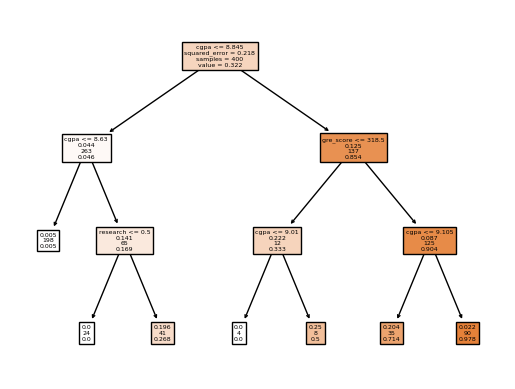

In [19]:
import sklearn.tree as tree

tree.plot_tree(dt, feature_names = x_train.columns,  
               max_depth=3, class_names = ['unlikely admit', 'likely admit'],
               label='root', filled=True)

print(tree.export_text(dt, feature_names = X.columns.tolist()))


<h1>Split Criteria</h1>

Gini impurity is the criteria for splitting the nodes. Gini impurity quantifies how impure groups are, at the root note the first split is chosen as the one to maximise information gain. 

<code>cgpa</code> is continuous so the split can happen at any value

In [13]:
def gini(data):
    """Calculate the Gini Impurity Score
    """
    data = pd.Series(data)
    return 1 - sum(data.value_counts(normalize=True)**2)
   
gi = gini(y_train)
print(f'Gini impurity at root: {round(gi,3)}')

def info_gain(left, right, current_impurity):
    """Information Gain associated with creating a node/split data.
    Input: left, right are data in left branch, right banch, respectively
    current_impurity is the data impurity before splitting into left, right branches
    """
    # weight for gini score of the left branch
    w = float(len(left)) / (len(left) + len(right))
    return current_impurity - w * gini(left) - (1 - w) * gini(right)

info_gain_list = []
for i in x_train.cgpa.unique():
    left = y_train[x_train.cgpa<=i]
    right = y_train[x_train.cgpa>i]
    info_gain_list.append([i, info_gain(left, right, gi)])

ig_table = pd.DataFrame(info_gain_list, columns=['split_value', 'info_gain']).sort_values('info_gain',ascending=False)
ig_table.head(10)


Gini impurity at root: 0.437


,split_value,info_gain
105,8.84,0.294324
37,8.90,0.292200
72,8.96,0.291139
138,8.85,0.289894
163,8.94,0.287844
79,8.83,0.287156
66,8.86,0.285500
154,8.88,0.284772
38,8.80,0.283650
97,8.97,0.282175


Text(0, 0.5, 'info gain')

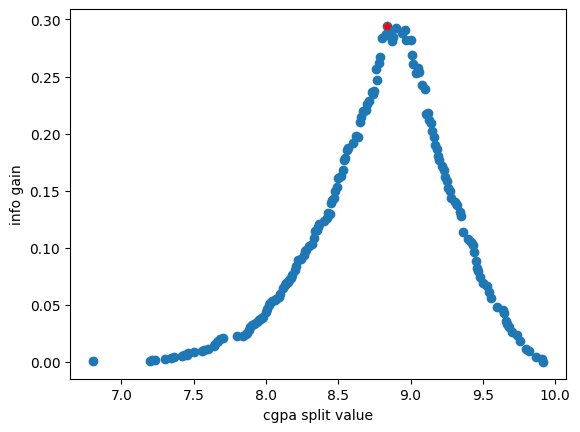

In [14]:
import matplotlib.pyplot as plt

plt.plot(ig_table['split_value'], ig_table['info_gain'],'o')
plt.plot(ig_table['split_value'].iloc[0], ig_table['info_gain'].iloc[0],'r*')
plt.xlabel('cgpa split value')
plt.ylabel('info gain')

<h1> Regression</h1>

For regression <code>chance_of_admit</code> is the target variable, it is a floating point between 0 and 1. 

The method and syntax is the same. The difference for the split criterion for regression is the mean squared error. This aligns with concepts covered in basic linear regression.

0.7934223224093973


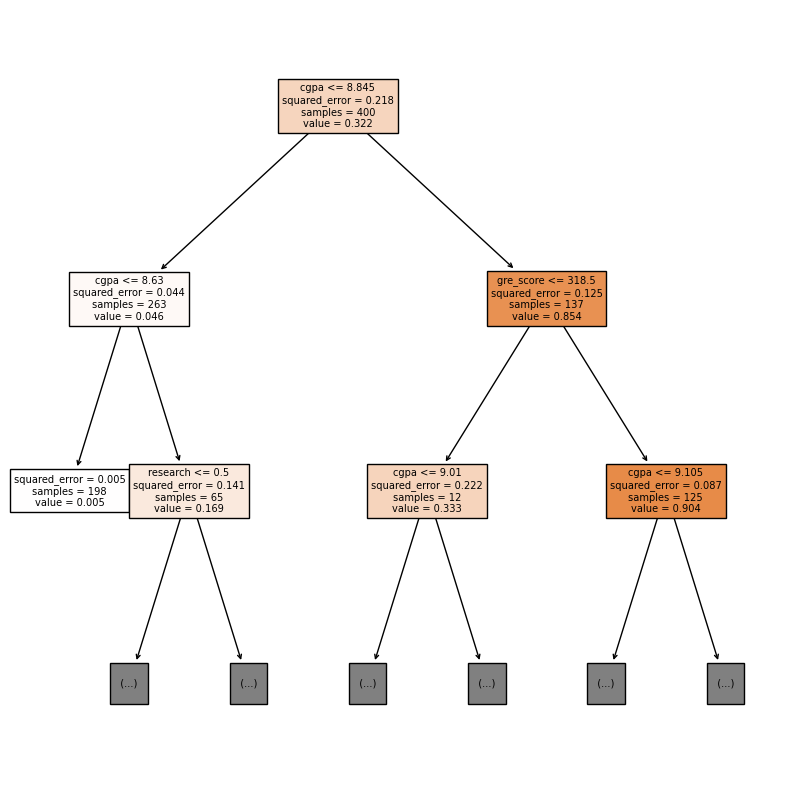

In [20]:
from sklearn.tree import DecisionTreeRegressor

x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.2)
dt = DecisionTreeRegressor(max_depth=3, ccp_alpha=0.001)
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)
print(dt.score(x_test, y_test))

plt.figure(figsize=(10,10))
tree.plot_tree(dt, feature_names = x_train.columns,  
               max_depth=2, filled=True);


In [21]:
y_train.mean()

0.3225

In [23]:
import numpy as np
np.mean((y_train - y_train.mean())**2)

0.21849375

<h1>Split Criteria</h1>
Classes are not split, instead the value is the average of all the sample that fit the logical split.

The logical split is evaluated using the MSE. The root node, the average target value is 0.323

To calculate the information gain or decrease in MSE after the split is used to determine the split for each value of <code>cpga</code>.

In [24]:
def mse(data):
    """Calculate the MSE of a data set
    """
    return np.mean((data - data.mean())**2)
   
def mse_gain(left, right, current_mse):
    """Information Gain (MSE) associated with creating a node/split data based on MSE.
    Input: left, right are data in left branch, right banch, respectively
    current_impurity is the data impurity before splitting into left, right branches
    """
    # weight for gini score of the left branch
    w = float(len(left)) / (len(left) + len(right))
    return current_mse - w * mse(left) - (1 - w) * mse(right)

m = mse(y_train)
print(f'MSE at root: {round(m,3)}')

mse_gain_list = []
for i in x_train.cgpa.unique():
    left = y_train[x_train.cgpa<=i]
    right = y_train[x_train.cgpa>i]
    mse_gain_list.append([i, mse_gain(left, right, m)])

mse_table = pd.DataFrame(mse_gain_list,columns=['split_value', 'info_gain']).sort_values('info_gain',ascending=False)
print(mse_table.head(10))

MSE at root: 0.218
     split_value  info_gain
105         8.84   0.147162
37          8.90   0.146100
72          8.96   0.145569
138         8.85   0.144947
163         8.94   0.143922
79          8.83   0.143578
66          8.86   0.142750
154         8.88   0.142386
38          8.80   0.141825
97          8.97   0.141088


Text(0, 0.5, 'info gain')

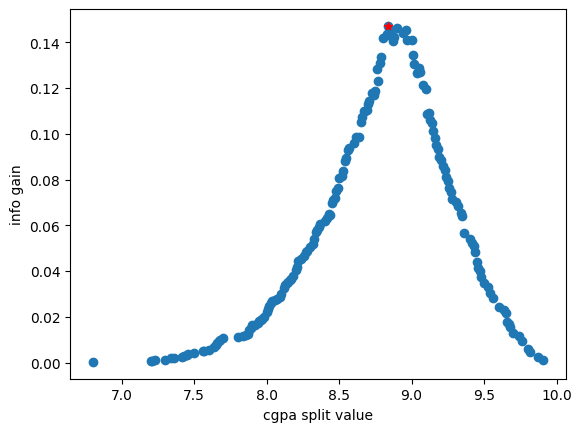

In [25]:
plt.plot(mse_table['split_value'], mse_table['info_gain'],'o')
plt.plot(mse_table['split_value'].iloc[0], mse_table['info_gain'].iloc[0],'r*')
plt.xlabel('cgpa split value')
plt.ylabel('info gain')

In [27]:
len(np.unique(dt.predict(x_train)))


6

Traversal of the tree is done in the same way as classification. When arriving at a leaf node the sample is assigned the average value of the samples in the leaf. 

Not all output values are possible, in the example 6 predicted values are possible.